> **NEW: troll+insult merged into a single `flaming` class** (`MERGE_TROLL_INSULT=True` in Section 2). `flaming` = troll OR insult (~50% of rows) — the two overlapping classes both models failed to separate. Set the flag `False` to reproduce the original 5-class setup.

# Bengali Cyberbullying Detection — Transformer Fine-Tuning (Track 2)
## BanglaBERT / MuRIL / XLM-R | Kaggle T4 x2 + mixed precision

**Goal:** beat the lightweight from-scratch ceiling (honest Macro-F1 ≈ 0.72) by fine-tuning a
**pretrained Bengali transformer**. These models already understand Bengali morphology, so they
typically reach **0.82-0.88 macro-F1** on this kind of task and they eliminate the ~15% OOV problem
of word-level FastText.

**Trade-off (read this):** the encoder is **~110M parameters**, so this notebook **intentionally
abandons the ~10M budget**. Use this when accuracy matters more than model size; use the
lightweight notebook (`bengali-cyberbullying-lightweight-v4.ipynb`) when the 10M cap is required.

**Design (kept consistent with the lightweight notebook so results are comparable):**
- Predicts the **4 toxic labels**; `neutral` is **derived** as `NOT(any toxic)`.
- **Split before anything**, dedup on cleaned text, hard zero-leakage assertions.
- Focal loss (multi-label), per-class threshold tuning, derived-neutral 5-class report.
- `nn.DataParallel` across both T4 GPUs + `torch.cuda.amp` mixed precision.

Default backbone: `csebuetnlp/banglabert`. If it is unavailable, the notebook automatically falls
back to `google/muril-base-cased`, then `xlm-roberta-base`.


In [1]:
# Section 1: Setup & Imports
!pip install -q transformers sentencepiece iterative-stratification

import os, re, math, random, time, json, copy, warnings
os.environ['TOKENIZERS_PARALLELISM'] = 'false'  # safety: avoid fast-tokenizer fork stall
import numpy as np
import pandas as pd
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader
from torch.optim import AdamW

from sklearn.metrics import (
    f1_score, classification_report, hamming_loss,
    roc_auc_score, average_precision_score
)
from iterstrat.ml_stratifiers import MultilabelStratifiedShuffleSplit
from transformers import AutoTokenizer, AutoModel, get_linear_schedule_with_warmup, get_cosine_schedule_with_warmup

import matplotlib.pyplot as plt
import seaborn as sns
warnings.filterwarnings('ignore'); sns.set_style('whitegrid')

SEED = 42
def set_seed(seed=SEED):
    random.seed(seed); np.random.seed(seed)
    torch.manual_seed(seed); torch.cuda.manual_seed_all(seed)
    torch.backends.cudnn.deterministic = True; torch.backends.cudnn.benchmark = False
set_seed(SEED)

NUM_GPUS = torch.cuda.device_count()
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f'PyTorch {torch.__version__} | Device: {device} | GPUs: {NUM_GPUS}')
for i in range(NUM_GPUS):
    p = torch.cuda.get_device_properties(i)
    print(f'  GPU {i}: {p.name} ({p.total_memory/1e9:.1f} GB)')


PyTorch 2.10.0+cu128 | Device: cuda | GPUs: 2
  GPU 0: Tesla T4 (15.6 GB)
  GPU 1: Tesla T4 (15.6 GB)


In [2]:
# Section 2: Configuration

class Config:
    DATA_PATH = '/kaggle/input/datasets/muhammedjunayed/bengalicyber/combined_multi_labeled_bengali_comments_balanced_13k_14k_plus_neutral_plus_threat300.csv'
    TEXT_COL = 'text'
    LABEL_COLS = ['vulgar', 'threat', 'troll', 'insult', 'neutral']
    TOXIC_COLS = ['vulgar', 'threat', 'troll', 'insult']
    NEUTRAL_COL = 'neutral'
    NUM_OUT = 4
    MERGE_TROLL_INSULT = True   # merge troll+insult -> 'flaming' (set False for original 5-class)

    # Backbone candidates (first that loads wins)
    MODEL_CANDIDATES = ['csebuetnlp/banglabert', 'google/muril-base-cased', 'xlm-roberta-base']

    MIN_WORDS = 2
    MAX_LEN = 128

    TEST_FRAC = 0.15
    VAL_FRAC = 0.15

    # Training
    BATCH_SIZE_PER_GPU = 16
    EPOCHS = 8
    LR = 1.5e-5
    HEAD_LR = 5e-5
    WEIGHT_DECAY = 0.03
    WARMUP_RATIO = 0.2
    MAX_GRAD_NORM = 0.5
    DROPOUT = 0.4
    HIDDEN_DROPOUT = 0.1
    LABEL_SMOOTHING = 0.10
    USE_AMP = True             # mixed precision on T4

    # Loss
    USE_FOCAL_LOSS = True
    FOCAL_GAMMA = 2.0

    # Regularization
    LLRD_FACTOR = 0.9
    RDROP_ALPHA = 1.0
    FREEZE_LAYERS = 4

    PATIENCE = 3
    THRESH_MIN = 0.30
    THRESH_MAX = 0.70
    THRESH_STEP = 0.02
    ENSEMBLE_SEEDS = [42, 7, 2024]

cfg = Config()
EFFECTIVE_BATCH = cfg.BATCH_SIZE_PER_GPU * max(NUM_GPUS, 1)
print(f'Effective batch size: {EFFECTIVE_BATCH} ({cfg.BATCH_SIZE_PER_GPU} x {max(NUM_GPUS,1)} GPU)')
print(f'Predicts {cfg.NUM_OUT} toxic labels; neutral derived. AMP={cfg.USE_AMP}')


Effective batch size: 32 (16 x 2 GPU)
Predicts 4 toxic labels; neutral derived. AMP=True


In [3]:
# Section 3: Load + light clean + dedup + derive neutral

data_paths = [
    cfg.DATA_PATH,
    f'/kaggle/input/datasets/muhammedjunayed/bengalicyber/{cfg.DATA_PATH}',
    f'/kaggle/input/bengali-cyberbullying-15k/{cfg.DATA_PATH}',
    f'./{cfg.DATA_PATH}',
]
df = None
for p in data_paths:
    if os.path.exists(p):
        df = pd.read_csv(p); print(f'Loaded: {p}'); break
if df is None:
    raise FileNotFoundError(f'Dataset not found. Tried: {data_paths}')
for col in cfg.LABEL_COLS:
    df[col] = df[col].astype(int)

# --- Merge troll+insult into a single 'flaming' class (recognized cyberbullying category) ---
if getattr(cfg, 'MERGE_TROLL_INSULT', False):
    df['flaming'] = ((df['troll'] == 1) | (df['insult'] == 1)).astype(int)
    cfg.TOXIC_COLS = ['vulgar', 'threat', 'flaming']
    cfg.LABEL_COLS = ['vulgar', 'threat', 'flaming', 'neutral']
    cfg.NUM_OUT = len(cfg.TOXIC_COLS)
    print("MERGE_TROLL_INSULT=True -> classes:", cfg.LABEL_COLS, "| NUM_OUT =", cfg.NUM_OUT)

# Light cleaning: drop URLs/mentions/emoji, collapse whitespace. Keep Bengali punctuation
# (transformers benefit from natural text) unlike the aggressive cleaning in the lightweight model.
URL_RE = re.compile(r'https?://\S+|www\.\S+')
MENTION_RE = re.compile(r'@\w+')
EMOJI_RE = re.compile(
    '[\U0001F600-\U0001F64F\U0001F300-\U0001F5FF'
    '\U0001F680-\U0001F6FF\U0001F900-\U0001F9FF\U00002702-\U000027B0]+', flags=re.UNICODE)

def light_clean(t):
    t = str(t)
    t = URL_RE.sub(' ', t); t = MENTION_RE.sub(' ', t); t = EMOJI_RE.sub(' ', t)
    return re.sub(r'\s+', ' ', t).strip()

df['clean_text'] = df[cfg.TEXT_COL].apply(light_clean)
df['_wc'] = df['clean_text'].str.split().str.len().fillna(0)
df = df[df['_wc'] >= cfg.MIN_WORDS].copy()
before = len(df)
df = df.groupby('clean_text', as_index=False)[cfg.LABEL_COLS].max()
print(f'Deduplicated on cleaned text: {before} -> {len(df)}')
tox = df[cfg.TOXIC_COLS].sum(axis=1) > 0
df[cfg.NEUTRAL_COL] = (~tox).astype(int)
df = df.reset_index(drop=True)
print('Per-class distribution:')
for c in cfg.LABEL_COLS:
    print(f'  {c:>8s}: {int(df[c].sum()):>5d} ({100*df[c].mean():.1f}%)')


Loaded: /kaggle/input/datasets/muhammedjunayed/bengalicyber/combined_multi_labeled_bengali_comments_balanced_13k_14k_plus_neutral_plus_threat300.csv
MERGE_TROLL_INSULT=True -> classes: ['vulgar', 'threat', 'flaming', 'neutral'] | NUM_OUT = 3
Deduplicated on cleaned text: 15457 -> 15320
Per-class distribution:
    vulgar:  3809 (24.9%)
    threat:  2149 (14.0%)
   flaming:  7706 (50.3%)
   neutral:  5469 (35.7%)


## Section 4: Stratified split (before anything) with zero-leakage guarantee

In [4]:
# Section 5: Stratified Train/Val/Test split

y = df[cfg.LABEL_COLS].values
msss1 = MultilabelStratifiedShuffleSplit(n_splits=1, test_size=cfg.TEST_FRAC, random_state=SEED)
tv_idx, test_idx = next(msss1.split(df, y))
df_tv = df.iloc[tv_idx].reset_index(drop=True)
msss2 = MultilabelStratifiedShuffleSplit(n_splits=1, test_size=cfg.VAL_FRAC/(1-cfg.TEST_FRAC), random_state=SEED)
tr_sub, val_sub = next(msss2.split(df_tv, df_tv[cfg.LABEL_COLS].values))
df_train = df_tv.iloc[tr_sub].reset_index(drop=True)
df_val   = df_tv.iloc[val_sub].reset_index(drop=True)
df_test  = df.iloc[test_idx].reset_index(drop=True)
print(f'Train {len(df_train)} | Val {len(df_val)} | Test {len(df_test)}')

tr = set(df_train['clean_text'])
assert not (tr & set(df_val['clean_text'])) and not (tr & set(df_test['clean_text'])), 'LEAKAGE!'
for name, d in [('train', df_train), ('val', df_val), ('test', df_test)]:
    tox = d[cfg.TOXIC_COLS].sum(axis=1) > 0
    assert int(((tox & (d[cfg.NEUTRAL_COL]==1)) | (~tox & (d[cfg.NEUTRAL_COL]==0))).sum()) == 0
print('Leakage = 0 and neutral consistent in all splits.')


Train 10711 | Val 2302 | Test 2307
Leakage = 0 and neutral consistent in all splits.


In [5]:
# Section 6: Tokenizer + Dataset + DataLoaders

tokenizer, MODEL_NAME = None, None
for name in cfg.MODEL_CANDIDATES:
    try:
        tokenizer = AutoTokenizer.from_pretrained(name)
        MODEL_NAME = name
        print(f'Loaded tokenizer: {name}')
        break
    except Exception as e:
        print(f'  tokenizer {name} failed: {type(e).__name__}')
assert tokenizer is not None, 'No tokenizer could be loaded'

class TxtDataset(Dataset):
    def __init__(self, df, tokenizer, cfg):
        self.texts = df['clean_text'].tolist()
        self.labels = df[cfg.TOXIC_COLS].values.astype(np.float32)
        self.tok = tokenizer; self.cfg = cfg
    def __len__(self): return len(self.texts)
    def __getitem__(self, i):
        enc = self.tok(self.texts[i], truncation=True, max_length=self.cfg.MAX_LEN,
                       padding='max_length', return_tensors='pt')
        return (enc['input_ids'].squeeze(0), enc['attention_mask'].squeeze(0),
                torch.FloatTensor(self.labels[i]))

train_ds = TxtDataset(df_train, tokenizer, cfg)
val_ds   = TxtDataset(df_val, tokenizer, cfg)
test_ds  = TxtDataset(df_test, tokenizer, cfg)
train_loader = DataLoader(train_ds, batch_size=EFFECTIVE_BATCH, shuffle=True, num_workers=2, pin_memory=True, drop_last=True)
val_loader   = DataLoader(val_ds, batch_size=EFFECTIVE_BATCH*2, shuffle=False, num_workers=2, pin_memory=True)
test_loader  = DataLoader(test_ds, batch_size=EFFECTIVE_BATCH*2, shuffle=False, num_workers=2, pin_memory=True)
print(f'Train batches {len(train_loader)} | Val {len(val_loader)} | Test {len(test_loader)}')


config.json:   0%|          | 0.00/586 [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/119 [00:00<?, ?B/s]

vocab.txt: 0.00B [00:00, ?B/s]

special_tokens_map.json:   0%|          | 0.00/112 [00:00<?, ?B/s]

Loaded tokenizer: csebuetnlp/banglabert
Train batches 334 | Val 36 | Test 37


In [6]:
# Section 7: Model (pretrained encoder + mean-pool + linear head) & Focal loss

class TransformerClassifier(nn.Module):
    def __init__(self, model_name, cfg):
        super().__init__()
        self.encoder = AutoModel.from_pretrained(model_name)
        hidden = self.encoder.config.hidden_size
        self.hidden_dropout = nn.Dropout(cfg.HIDDEN_DROPOUT)
        self.dropout = nn.Dropout(cfg.DROPOUT)
        self.layer_norm = nn.LayerNorm(hidden)
        self.classifier = nn.Linear(hidden, cfg.NUM_OUT)
        self.num_dropout_samples = 5
        nn.init.xavier_uniform_(self.classifier.weight); nn.init.zeros_(self.classifier.bias)

    def forward(self, input_ids, attention_mask):
        out = self.encoder(input_ids=input_ids, attention_mask=attention_mask)
        hs = out.last_hidden_state                       # (B, T, H)
        hs = self.hidden_dropout(hs)
        mask = attention_mask.unsqueeze(-1).float()
        pooled = (hs * mask).sum(1) / mask.sum(1).clamp(min=1e-6)  # masked mean pool
        pooled = self.layer_norm(pooled)
        if self.training:
            # Multi-sample dropout: apply dropout N times and average logits
            logits = torch.stack(
                [self.classifier(self.dropout(pooled)) for _ in range(self.num_dropout_samples)],
                dim=0
            ).mean(dim=0)
        else:
            logits = self.classifier(self.dropout(pooled))
        return logits

class FocalBCELoss(nn.Module):
    def __init__(self, gamma=2.0, smoothing=0.0):
        super().__init__(); self.gamma = gamma; self.smoothing = smoothing
    def forward(self, logits, targets):
        if self.smoothing > 0:
            targets = targets * (1 - self.smoothing) + 0.5 * self.smoothing
        bce = F.binary_cross_entropy_with_logits(logits, targets, reduction='none')
        p_t = targets * torch.sigmoid(logits) + (1 - targets) * (1 - torch.sigmoid(logits))
        return ((1 - p_t) ** self.gamma * bce).mean()

set_seed(SEED)
model = TransformerClassifier(MODEL_NAME, cfg)
total = sum(p.numel() for p in model.parameters())
print(f'Model: {MODEL_NAME} | total params: {total:,} ({total/1e6:.1f}M) -- intentionally > 10M')
criterion = FocalBCELoss(cfg.FOCAL_GAMMA, cfg.LABEL_SMOOTHING) if cfg.USE_FOCAL_LOSS else nn.BCEWithLogitsLoss()
if NUM_GPUS > 1:
    model = nn.DataParallel(model); print(f'DataParallel across {NUM_GPUS} GPUs (T4 x2).')
model = model.to(device)


pytorch_model.bin:   0%|          | 0.00/443M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/197 [00:00<?, ?it/s]

ElectraModel LOAD REPORT from: csebuetnlp/banglabert
Key                                               | Status     |  | 
--------------------------------------------------+------------+--+-
discriminator_predictions.dense_prediction.bias   | UNEXPECTED |  | 
discriminator_predictions.dense.weight            | UNEXPECTED |  | 
electra.embeddings.position_ids                   | UNEXPECTED |  | 
discriminator_predictions.dense.bias              | UNEXPECTED |  | 
discriminator_predictions.dense_prediction.weight | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


Model: csebuetnlp/banglabert | total params: 110,030,595 (110.0M) -- intentionally > 10M
DataParallel across 2 GPUs (T4 x2).


model.safetensors:   0%|          | 0.00/443M [00:00<?, ?B/s]

In [7]:
# Section 8: Optimizer (LLRD, freeze bottom layers, cosine schedule) + AMP

base = model.module if hasattr(model, 'module') else model

# Freeze bottom N transformer layers and embeddings
for param in base.encoder.embeddings.parameters():
    param.requires_grad = False
for i in range(cfg.FREEZE_LAYERS):
    for param in base.encoder.encoder.layer[i].parameters():
        param.requires_grad = False

# Layer-wise Learning Rate Decay (LLRD)
no_decay = ['bias', 'LayerNorm.weight']
num_layers = base.encoder.config.num_hidden_layers
groups = []

# Embedding parameters (lowest LR) - skip if frozen
emb_lr = cfg.LR * (cfg.LLRD_FACTOR ** num_layers)
emb_params_wd = [p for n, p in base.encoder.embeddings.named_parameters() if p.requires_grad and not any(nd in n for nd in no_decay)]
emb_params_no_wd = [p for n, p in base.encoder.embeddings.named_parameters() if p.requires_grad and any(nd in n for nd in no_decay)]
if emb_params_wd:
    groups.append({'params': emb_params_wd, 'weight_decay': cfg.WEIGHT_DECAY, 'lr': emb_lr})
if emb_params_no_wd:
    groups.append({'params': emb_params_no_wd, 'weight_decay': 0.0, 'lr': emb_lr})

# Encoder layers with LLRD
for i in range(num_layers):
    layer_lr = cfg.LR * (cfg.LLRD_FACTOR ** (num_layers - 1 - i))
    layer_params_wd = [p for n, p in base.encoder.encoder.layer[i].named_parameters() if p.requires_grad and not any(nd in n for nd in no_decay)]
    layer_params_no_wd = [p for n, p in base.encoder.encoder.layer[i].named_parameters() if p.requires_grad and any(nd in n for nd in no_decay)]
    if layer_params_wd:
        groups.append({'params': layer_params_wd, 'weight_decay': cfg.WEIGHT_DECAY, 'lr': layer_lr})
    if layer_params_no_wd:
        groups.append({'params': layer_params_no_wd, 'weight_decay': 0.0, 'lr': layer_lr})

# Pooler (if exists)
if hasattr(base.encoder, 'pooler') and base.encoder.pooler is not None:
    pooler_params = [p for p in base.encoder.pooler.parameters() if p.requires_grad]
    if pooler_params:
        groups.append({'params': pooler_params, 'weight_decay': cfg.WEIGHT_DECAY, 'lr': cfg.LR})

# Head parameters (LayerNorm + classifier)
head_params_wd = []
head_params_no_wd = []
for module in [base.layer_norm, base.classifier]:
    for n, p in module.named_parameters():
        if p.requires_grad:
            if any(nd in n for nd in no_decay):
                head_params_no_wd.append(p)
            else:
                head_params_wd.append(p)
if head_params_wd:
    groups.append({'params': head_params_wd, 'weight_decay': cfg.WEIGHT_DECAY, 'lr': cfg.HEAD_LR})
if head_params_no_wd:
    groups.append({'params': head_params_no_wd, 'weight_decay': 0.0, 'lr': cfg.HEAD_LR})

optimizer = AdamW(groups)
total_steps = cfg.EPOCHS * len(train_loader)
warmup_steps = int(total_steps * cfg.WARMUP_RATIO)
scheduler = get_cosine_schedule_with_warmup(optimizer, warmup_steps, total_steps)
scaler = torch.cuda.amp.GradScaler(enabled=cfg.USE_AMP and device.type == 'cuda')

trainable = sum(p.numel() for p in base.parameters() if p.requires_grad)
frozen = sum(p.numel() for p in base.parameters() if not p.requires_grad)
print(f'Total steps {total_steps} | Warmup {warmup_steps} | Schedule: cosine')
print(f'Trainable params: {trainable:,} | Frozen params: {frozen:,}')
print(f'LLRD factor: {cfg.LLRD_FACTOR} | Freeze layers: {cfg.FREEZE_LAYERS}')


Total steps 2672 | Warmup 534 | Schedule: cosine
Trainable params: 56,706,819 | Frozen params: 53,323,776
LLRD factor: 0.9 | Freeze layers: 4


In [8]:
# Section 9: Training loop (AMP, DataParallel, early stopping, R-Drop, derived-neutral val metric)

def neutral_from_toxic(b):
    return np.concatenate([b, (b.sum(axis=1) == 0).astype(int).reshape(-1,1)], axis=1)

def symmetric_kl_divergence(p, q):
    """Compute symmetric KL divergence for independent Bernoulli outputs (sigmoid)."""
    eps = 1e-7
    p = p.clamp(min=eps, max=1 - eps)
    q = q.clamp(min=eps, max=1 - eps)
    # Full Bernoulli KL: p*log(p/q) + (1-p)*log((1-p)/(1-q))
    kl_pq = (p * (p.log() - q.log()) + (1 - p) * ((1 - p).log() - (1 - q).log())).sum(dim=-1).mean()
    kl_qp = (q * (q.log() - p.log()) + (1 - q) * ((1 - q).log() - (1 - p).log())).sum(dim=-1).mean()
    return (kl_pq + kl_qp) / 2

def train_one_epoch(model, loader, gstep):
    model.train(); tot = 0.0
    for input_ids, attn, labels in loader:
        input_ids, attn, labels = input_ids.to(device), attn.to(device), labels.to(device)
        optimizer.zero_grad()
        with torch.cuda.amp.autocast(enabled=cfg.USE_AMP and device.type=='cuda'):
            # R-Drop: two forward passes with different dropout masks
            logits1 = model(input_ids, attn)
            logits2 = model(input_ids, attn)
            # Average logits for focal loss computation
            avg_logits = (logits1 + logits2) / 2
            loss = criterion(avg_logits, labels)
            # Symmetric KL divergence between the two predictions
            p1 = torch.sigmoid(logits1)
            p2 = torch.sigmoid(logits2)
            kl_loss = symmetric_kl_divergence(p1, p2)
            loss = loss + cfg.RDROP_ALPHA * kl_loss
        scaler.scale(loss).backward()
        scaler.unscale_(optimizer)
        nn.utils.clip_grad_norm_(model.parameters(), cfg.MAX_GRAD_NORM)
        scaler.step(optimizer); scaler.update(); scheduler.step(); gstep += 1
        tot += loss.item()
    return tot/len(loader), gstep

@torch.no_grad()
def evaluate(model, loader):
    model.eval(); tot=0.0; P, L = [], []
    # Get base model for multi-sample dropout at eval time
    base = model.module if hasattr(model, 'module') else model
    N = base.num_dropout_samples  # match training (N=5)
    for input_ids, attn, labels in loader:
        input_ids, attn, labels = input_ids.to(device), attn.to(device), labels.to(device)
        with torch.cuda.amp.autocast(enabled=cfg.USE_AMP and device.type=='cuda'):
            # Multi-sample dropout at eval: average N forward passes with dropout active
            out = base.encoder(input_ids=input_ids, attention_mask=attn)
            hs = out.last_hidden_state
            mask = attn.unsqueeze(-1).float()
            pooled = (hs * mask).sum(1) / mask.sum(1).clamp(min=1e-6)
            pooled = base.layer_norm(pooled)
            # Enable dropout for multi-sample averaging
            base.dropout.train()
            logits = torch.stack(
                [base.classifier(base.dropout(pooled)) for _ in range(N)],
                dim=0
            ).mean(dim=0)
            base.dropout.eval()
            loss = criterion(logits, labels)
        tot += loss.item(); P.append(torch.sigmoid(logits).float().cpu().numpy()); L.append(labels.cpu().numpy())
    P, L = np.vstack(P), np.vstack(L)
    f1 = f1_score(neutral_from_toxic((L>0.5).astype(int)), neutral_from_toxic((P>0.5).astype(int)), average='macro', zero_division=0)
    pc = f1_score(neutral_from_toxic((L>0.5).astype(int)), neutral_from_toxic((P>0.5).astype(int)), average=None, zero_division=0)
    return tot/len(loader), f1, pc, P, L

history = {'train_loss': [], 'val_loss': [], 'val_f1': [], 'val_per_class_f1': []}
best_f1, best_epoch, patience, gstep, best_state = 0.0, 0, 0, 0, None
print('='*80)
for epoch in range(1, cfg.EPOCHS+1):
    t0 = time.time()
    tl, gstep = train_one_epoch(model, train_loader, gstep)
    vl, vf1, vpc, _, _ = evaluate(model, val_loader)
    history['train_loss'].append(tl); history['val_loss'].append(vl)
    history['val_f1'].append(vf1); history['val_per_class_f1'].append(vpc.tolist())
    if vf1 > best_f1:
        best_f1, best_epoch = vf1, epoch
        best_state = copy.deepcopy((model.module if hasattr(model,'module') else model).state_dict())
        patience = 0; mark=' *BEST*'
    else:
        patience += 1; mark=''
    print(f'Epoch {epoch}/{cfg.EPOCHS} | TrLoss {tl:.4f} | VaLoss {vl:.4f} | VaF1 {vf1:.4f} | {time.time()-t0:.0f}s{mark}')
    if patience >= cfg.PATIENCE:
        print(f'Early stopping at epoch {epoch}.'); break
print('='*80)
print(f'Best epoch {best_epoch} | Best Val Macro-F1 {best_f1:.4f}')
(model.module if hasattr(model,'module') else model).load_state_dict(best_state)


Epoch 1/8 | TrLoss 0.3896 | VaLoss 0.1248 | VaF1 0.5660 | 121s *BEST*
Epoch 2/8 | TrLoss 0.2024 | VaLoss 0.1030 | VaF1 0.6682 | 119s *BEST*
Epoch 3/8 | TrLoss 0.1185 | VaLoss 0.0813 | VaF1 0.7603 | 120s *BEST*
Epoch 4/8 | TrLoss 0.0961 | VaLoss 0.0796 | VaF1 0.7765 | 119s *BEST*
Epoch 5/8 | TrLoss 0.0882 | VaLoss 0.0753 | VaF1 0.7941 | 119s *BEST*
Epoch 6/8 | TrLoss 0.0838 | VaLoss 0.0731 | VaF1 0.8001 | 119s *BEST*
Epoch 7/8 | TrLoss 0.0808 | VaLoss 0.0724 | VaF1 0.7974 | 119s
Epoch 8/8 | TrLoss 0.0798 | VaLoss 0.0723 | VaF1 0.7991 | 119s
Best epoch 6 | Best Val Macro-F1 0.8001


<All keys matched successfully>

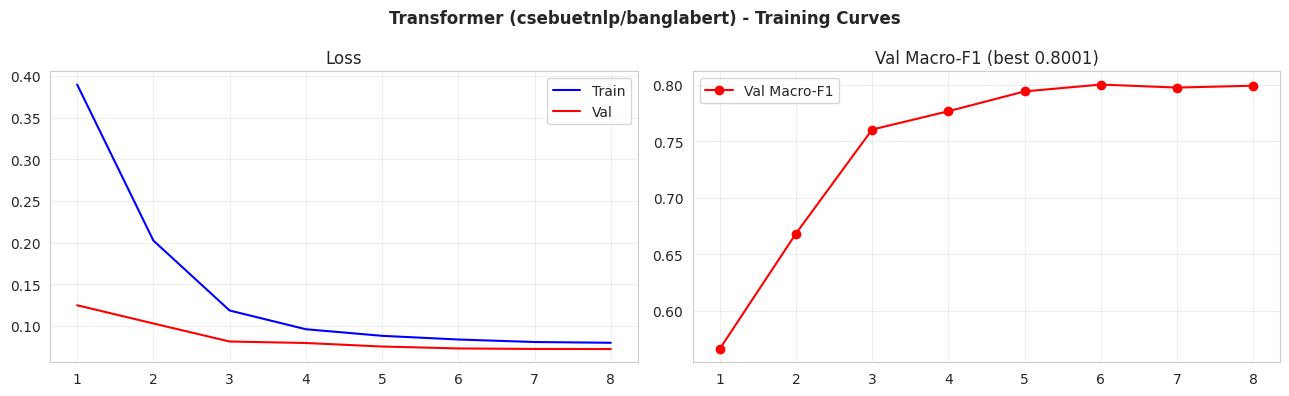

In [9]:
# Section 10: Curves
fig, ax = plt.subplots(1, 2, figsize=(13, 4))
ep = range(1, len(history['train_loss'])+1)
ax[0].plot(ep, history['train_loss'], 'b-', label='Train'); ax[0].plot(ep, history['val_loss'], 'r-', label='Val')
ax[0].set_title('Loss'); ax[0].legend(); ax[0].grid(alpha=0.3)
ax[1].plot(ep, history['val_f1'], 'r-o', label='Val Macro-F1')
ax[1].set_title(f'Val Macro-F1 (best {best_f1:.4f})'); ax[1].legend(); ax[1].grid(alpha=0.3)
plt.suptitle(f'Transformer ({MODEL_NAME}) - Training Curves', fontweight='bold')
plt.tight_layout(); plt.savefig('transformer_curves.png', dpi=150, bbox_inches='tight'); plt.show()


In [10]:
# Section 11: Per-class threshold tuning on validation

_, _, _, val_preds, val_labels = evaluate(model, val_loader)

def tune_thresholds(preds, labels, cfg):
    grid = np.arange(cfg.THRESH_MIN, cfg.THRESH_MAX+1e-9, cfg.THRESH_STEP)
    best = np.full(preds.shape[1], 0.5)
    for c in range(preds.shape[1]):
        bf = -1.0
        for t in grid:
            f1 = f1_score(labels[:, c], (preds[:, c] > t).astype(int), zero_division=0)
            if f1 > bf: bf, best[c] = f1, t
    return best

tuned = tune_thresholds(val_preds, val_labels, cfg)
print('Tuned thresholds:', {c: round(float(t),2) for c,t in zip(cfg.TOXIC_COLS, tuned)})

def apply_thresholds(preds, th):
    out = np.zeros_like(preds)
    for c in range(preds.shape[1]): out[:, c] = (preds[:, c] > th[c]).astype(int)
    return out
def to5(b): return np.concatenate([b, (b.sum(axis=1)==0).astype(int).reshape(-1,1)], axis=1)


Tuned thresholds: {'vulgar': 0.5, 'threat': 0.5, 'flaming': 0.48}


In [11]:
# Section 12: Final test evaluation (derive neutral, report all 5 classes)

@torch.no_grad()
def predict_probs(model, loader):
    model.eval(); P, L = [], []
    for input_ids, attn, y in loader:
        with torch.cuda.amp.autocast(enabled=cfg.USE_AMP and device.type=='cuda'):
            logits = model(input_ids.to(device), attn.to(device))
        P.append(torch.sigmoid(logits).float().cpu().numpy()); L.append(y.numpy())
    return np.vstack(P), np.vstack(L)

test_probs, test_toxic = predict_probs(model, test_loader)
test_pred5 = to5(apply_thresholds(test_probs, tuned))
test_true5 = to5((test_toxic > 0.5).astype(int))
test_probs5 = np.concatenate([test_probs, 1.0 - test_probs.max(axis=1, keepdims=True)], axis=1)

macro_f1 = f1_score(test_true5, test_pred5, average='macro', zero_division=0)
micro_f1 = f1_score(test_true5, test_pred5, average='micro', zero_division=0)
weighted_f1 = f1_score(test_true5, test_pred5, average='weighted', zero_division=0)
h_loss = hamming_loss(test_true5, test_pred5)
try: roc_auc = roc_auc_score(test_true5, test_probs5, average='macro')
except ValueError: roc_auc = float('nan')
try: pr_auc = average_precision_score(test_true5, test_probs5, average='macro')
except ValueError: pr_auc = float('nan')

print('='*64); print(f'   FINAL TEST EVALUATION (transformer: {MODEL_NAME})'); print('='*64)
print(f'  Macro-F1: {macro_f1:.4f} | Micro-F1: {micro_f1:.4f} | Weighted-F1: {weighted_f1:.4f}')
print(f'  Hamming: {h_loss:.4f} | ROC-AUC: {roc_auc:.4f} | PR-AUC: {pr_auc:.4f}')
print('='*64)
print(classification_report(test_true5, test_pred5, target_names=cfg.LABEL_COLS, digits=4, zero_division=0))


   FINAL TEST EVALUATION (transformer: csebuetnlp/banglabert)
  Macro-F1: 0.8031 | Micro-F1: 0.8097 | Weighted-F1: 0.8091
  Hamming: 0.1204 | ROC-AUC: 0.9413 | PR-AUC: 0.8962
              precision    recall  f1-score   support

      vulgar     0.8571    0.7986    0.8268       571
      threat     0.8303    0.7143    0.7679       322
     flaming     0.7590    0.8910    0.8197      1156
     neutral     0.8060    0.7902    0.7980       820

   micro avg     0.7960    0.8240    0.8097      2869
   macro avg     0.8131    0.7985    0.8031      2869
weighted avg     0.8000    0.8240    0.8091      2869
 samples avg     0.7921    0.8169    0.7946      2869



In [12]:
# Section 13: Save model + summary

base_model = model.module if hasattr(model, 'module') else model
torch.save({'model_state_dict': base_model.state_dict(),
            'model_name': MODEL_NAME,
            'thresholds': tuned.tolist(),
            'toxic_cols': cfg.TOXIC_COLS,
            'best_epoch': best_epoch, 'best_val_f1': best_f1,
            'test_macro_f1': macro_f1}, 'bengali_transformer_best.pt')
summary = {
    'version': 'transformer',
    'model_name': MODEL_NAME,
    'total_params': int(sum(p.numel() for p in base_model.parameters())),
    'predicts': cfg.TOXIC_COLS, 'neutral': 'derived as NOT(any toxic)',
    'hardware': f'{NUM_GPUS}x GPU (DataParallel + AMP)',
    'best_epoch': best_epoch, 'best_val_macro_f1': round(best_f1, 4),
    'test_macro_f1': round(macro_f1, 4), 'test_micro_f1': round(micro_f1, 4),
    'tuned_thresholds': {c: round(float(t),2) for c,t in zip(cfg.TOXIC_COLS, tuned)},
}
with open('transformer_summary.json', 'w') as f: json.dump(summary, f, indent=2, ensure_ascii=False)
print('Saved bengali_transformer_best.pt and transformer_summary.json')
print(f'FINAL: Test Macro-F1 = {macro_f1:.4f} | Backbone = {MODEL_NAME}')


Saved bengali_transformer_best.pt and transformer_summary.json
FINAL: Test Macro-F1 = 0.8031 | Backbone = csebuetnlp/banglabert


## Section 14: Notes & tips

- **Backbone:** `csebuetnlp/banglabert` is usually best for Bengali. For best BanglaBERT results,
  the authors recommend normalizing text with their `normalizer` package
  (`pip install git+https://github.com/csebuetnlp/normalizer`); plug it into `light_clean` if you
  attach it. MuRIL and XLM-R need no extra normalizer.
- **Kaggle:** set accelerator to **GPU T4 x2**. AMP + `nn.DataParallel` keep both GPUs busy; if you
  hit OOM, lower `BATCH_SIZE_PER_GPU` or `MAX_LEN`.
- **Why no augmentation here:** pretrained encoders fine-tuned for a few epochs with weight decay
  generalize well on ~12k samples, so synthetic augmentation is usually unnecessary (and can hurt).
- **Expected:** macro-F1 ≈ 0.82-0.88 (vs ≈0.72-0.77 for the lightweight model). `troll`/`insult`
  remain the hardest classes due to subjective, overlapping labels.
- **Parameter budget:** ~110M — this notebook deliberately trades the ~10M cap for accuracy.
